# Aggregate Results

Loads the raw per-day evaluation data `eval_raw.py`'s `run_full_evaluation_grid` collects into `8_testing/results/raw_daily/` and provides the readers used to cross-compare forecasters/archetypes. `eval_raw.py` is collection only -- it never reads `raw_daily/` back; all querying/aggregation (including the unfiltered `load_all_pairs`) lives here instead.

`load_all_pairs`/`load_single_price`/`load_dual_price` all rely on the same schema-consistency invariant: every parquet file under `raw_daily/` must share the current column schema. If `evaluate_one_pair`'s columns ever change, `raw_daily/` needs to be wiped and fully regenerated before re-running this notebook.

In [1]:
import pandas as pd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from eval_raw import RAW_DAILY_DIR

pd.set_option("display.width", 160)

In [2]:
def load_all_pairs() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR)


def load_single_price() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "single-price")])


def load_dual_price() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "dual-price")])

## Load

Requires `run_full_evaluation_grid()` to have been run at least once (see `eval_raw.py`) -- `raw_daily/` is empty until then.

In [3]:
df_single = load_single_price()
df_dual = load_dual_price()
print(f"single-price: {len(df_single)} rows, dual-price: {len(df_dual)} rows")
df_single.head()

single-price: 4026 rows, dual-price: 4026 rows


,forecaster_id,price_mode,archetype_name,day,date,total_cost,regret_v_oracle,C_da,C_imb,throughput_MWh,...,crps,bias_MW,p_ch_raw,p_dis_raw,p_ch_r,p_dis_r,soc,p_imb,mean,realised
0,baseline,single-price,balanced,0,2019-07-01 00:00:00+00:00,959.700004,32.836405,990.907096,-31.207092,19.425526,...,0.280942,0.065371,"[0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.71, 0.0, 0.0, 0.0, 0.0, 1.8000000000000003,...","[0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.71, 0.0, 0.0, 0.0, 0.0, 1.8000000000000003,...","[0.20000000000000018, 0.20000000000000018, 2.1...","[-0.016698737566767097, -0.06189280814946452, ...","[1.6266987518718818, 1.5218928462964372, 1.447...","[1.6100000143051147, 1.4600000381469727, 1.419..."
1,baseline,single-price,balanced,1,2019-07-02 00:00:00+00:00,835.592088,71.925924,1022.691693,-187.099605,19.625789,...,0.183748,0.269050,"[0.0, 0.0, 0.0, 2.0, 0.10526315789473695, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.80000000...","[0.0, 0.0, 0.0, 2.0, 0.10526315789473695, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.80000000...","[2.0, 2.0, 2.0, 3.9, 4.0, 4.0, 4.0, 2.10526315...","[-0.03908308296639973, -0.05546308201930983, -...","[1.619083125881744, 1.5054631297030256, 1.4237...","[1.5800000429153442, 1.4500000476837158, 1.379..."
2,baseline,single-price,balanced,2,2019-07-03 00:00:00+00:00,777.201399,-93.759859,764.557600,12.643799,19.625789,...,0.226859,-0.143013,"[2.0, 0.0, 0.10526315789473695, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.800...","[2.0, 0.0, 0.10526315789473695, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.8, ...","[3.9, 3.9, 4.0, 4.0, 4.0, 4.0, 4.0, 1.89473684...","[0.06475010354534838, -0.016414830753082477, 0...","[1.5852498726127935, 1.4764148689000551, 1.391...","[1.649999976158142, 1.4600000381469727, 1.3999..."
3,baseline,single-price,balanced,3,2019-07-04 00:00:00+00:00,681.960513,22.966601,874.331125,-192.370612,16.021053,...,0.157993,0.210801,"[0.0, 0.0, 0.10526315789473695, 2.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8000000000000...","[0.0, 0.0, 0.10526315789473695, 2.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8000000000000...","[2.0, 2.0, 2.1, 4.0, 4.0, 4.0, 2.1052631578947...","[0.017546833078194934, -0.019100664831997127, ...","[1.5924531812269198, 1.4891006934422266, 1.412...","[1.6100000143051147, 1.4700000286102295, 1.409..."
4,baseline,single-price,balanced,4,2019-07-05 00:00:00+00:00,568.833181,-13.588862,961.024998,-392.191817,19.625789,...,0.287408,0.396028,"[0.0, 0.0, 2.0, 0.10526315789473695, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.800...","[0.0, 0.0, 2.0, 0.10526315789473695, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.8, ...","[2.0, 2.0, 3.9, 4.0, 4.0, 4.0, 4.0, 1.89473684...","[-0.03539220289570255, -0.040629834307757795, ...","[1.6153922458110468, 1.4906298819914736, 1.413...","[1.5800000429153442, 1.4500000476837158, 1.379..."


## Shared helpers

`all_df` is the full unfiltered table (`load_all_pairs()`). Balanced archetype only now --
the earlier short_sharp/long_slow archetype grid (and the Q2/Q3 sections that compared
across it) was retired when the project narrowed to a balanced-only, single-vs-dual-price
comparison; see git history if that archetype-modulation/transfer analysis is ever needed
again.

`dfl_id(mode)` maps a price_mode onto the DFL forecaster_id trained under it --
`dfl_1stage_{mode}.pt` (see `train_dfl_forecasts.py`/`eval_raw.FORECASTERS`).

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def dfl_id(mode: str) -> str:
    return f"dfl_1stage_{mode}"


all_df = load_all_pairs()
print(f"all_df: {len(all_df)} rows | forecaster_ids: {sorted(all_df['forecaster_id'].unique())} | "
      f"archetypes: {sorted(all_df['archetype_name'].unique())} | "
      f"days/pair: {all_df.groupby(['forecaster_id', 'price_mode', 'archetype_name']).size().min()}"
      f"-{all_df.groupby(['forecaster_id', 'price_mode', 'archetype_name']).size().max()}")

all_df: 8052 rows | forecaster_ids: ['baseline', 'crps_only_retrained', 'crps_only_retrained_seed20240802', 'crps_only_retrained_seed20240803', 'crps_only_retrained_seed20240804', 'crps_only_retrained_seed20240805', 'dfl_1stage_dual-price', 'dfl_1stage_dual-price_seed20240802', 'dfl_1stage_dual-price_seed20240803', 'dfl_1stage_dual-price_seed20240804', 'dfl_1stage_dual-price_seed20240805', 'dfl_1stage_single-price', 'dfl_1stage_single-price_seed20240802', 'dfl_1stage_single-price_seed20240803', 'dfl_1stage_single-price_seed20240804', 'dfl_1stage_single-price_seed20240805'] | archetypes: ['balanced'] | days/pair: 366-366


## Q1 -- Does DFL reduce cost (with an accuracy trade-off)?

Balanced archetype (the only one trained/evaluated now), single & dual-price. Compares
`baseline` (single seed, not seed-averaged -- deliberately out of scope, see
`9_analysis/why_dfl_helps.md` Section 7) against `crps_only_retrained` (the missing
control: baseline weights fine-tuned on pinball loss ALONE, same training budget as
every DFL corner, no economic term) and the balanced-trained DFL checkpoint
(`dfl_id(mode)`), **both now seed-averaged over N=5 seeds** (20240801, the original, plus
20240802-20240805 -- see `train_crps_only.py`/`train_dfl_forecasts.py --seed`), matching
Beichter et al. (2025)'s own 5-seed convention (`9_analysis/beichter_et_al_relation.md`)
so this project's evidentiary standard is comparable to the positive result it's being
contrasted against.

Table columns: mean daily cost (mean +/- std across seeds), % change vs baseline (mean
+/- std, plus min/max range -- the range matters here, since the mean alone can hide a
result that crosses zero seed to seed), win rate, mean CRPS, mean/total absolute
imbalance volume. No significance test for now (Wilcoxon removed by request -- may be
added back later).

**Pairing note**: `evaluate_one_pair` silently `continue`s past any day its solve raises
on, so a forecaster's day set is not guaranteed to match another's 1:1 by row position.
Every paired comparison below joins on `day` rather than stacking positionally, and warns
if the join drops any days.

In [5]:
SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]


def seed_variant(base_id: str, seed: int) -> str:
    return base_id if seed == 20240801 else f"{base_id}_seed{seed}"


def q1_pair(mode: str) -> pd.DataFrame:
    dfl_forecaster = dfl_id(mode)
    base = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                  & (all_df["forecaster_id"] == "baseline")].set_index("day")
    base_daily_abs_imb = base["p_imb"].apply(lambda x: np.abs(np.asarray(x)).sum())

    rows = [{
        "market": mode, "forecaster": "baseline", "n_seeds": 1,
        "mean_daily_cost": base["total_cost"].mean(), "std_daily_cost": np.nan,
        "pct_change_mean": np.nan, "pct_change_std": np.nan, "pct_change_min": np.nan, "pct_change_max": np.nan,
        "win_rate_mean": np.nan, "win_rate_std": np.nan,
        "mean_crps": base["crps"].mean(), "std_crps": np.nan,
        "mean_abs_daily_imbalance_MWh": base_daily_abs_imb.mean(), "std_abs_daily_imbalance_MWh": np.nan,
        "total_abs_imbalance_MWh": base_daily_abs_imb.sum(), "std_total_abs_imbalance_MWh": np.nan,
    }]

    for label, base_id in [("crps_only_retrained", "crps_only_retrained"), (dfl_forecaster, dfl_forecaster)]:
        pcts, wins, costs, crpss, imbs, totals = [], [], [], [], [], []
        for seed in SEEDS:
            fid = seed_variant(base_id, seed)
            frame = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                            & (all_df["forecaster_id"] == fid)].set_index("day")
            paired = base[["total_cost"]].join(frame[["total_cost"]], lsuffix="_base", rsuffix="_x", how="inner")
            if len(paired) < max(len(base), len(frame)):
                print(f"  [{mode}/{fid}] WARNING: {len(base)} baseline days, {len(frame)} days, "
                      f"{len(paired)} after inner join on 'day' -- some day(s) dropped")
            delta = paired["total_cost_x"] - paired["total_cost_base"]
            daily_abs_imb = frame["p_imb"].apply(lambda x: np.abs(np.asarray(x)).sum())
            pcts.append(100 * delta.mean() / paired["total_cost_base"].mean())
            wins.append(100 * (delta < 0).mean())
            costs.append(frame["total_cost"].mean())
            crpss.append(frame["crps"].mean())
            imbs.append(daily_abs_imb.mean())
            totals.append(daily_abs_imb.sum())
        pcts, wins, costs, crpss, imbs, totals = (np.array(a) for a in (pcts, wins, costs, crpss, imbs, totals))
        print(f"  [{mode}/{label}] per-seed pct_change: {[f'{p:+.3f}' for p in pcts]}")
        rows.append({
            "market": mode, "forecaster": label, "n_seeds": len(SEEDS),
            "mean_daily_cost": costs.mean(), "std_daily_cost": costs.std(),
            "pct_change_mean": pcts.mean(), "pct_change_std": pcts.std(),
            "pct_change_min": pcts.min(), "pct_change_max": pcts.max(),
            "win_rate_mean": wins.mean(), "win_rate_std": wins.std(),
            "mean_crps": crpss.mean(), "std_crps": crpss.std(),
            "mean_abs_daily_imbalance_MWh": imbs.mean(), "std_abs_daily_imbalance_MWh": imbs.std(),
            "total_abs_imbalance_MWh": totals.mean(), "std_total_abs_imbalance_MWh": totals.std(),
        })
    return pd.DataFrame(rows)


q1_table = pd.concat([q1_pair("single-price"), q1_pair("dual-price")], ignore_index=True)
q1_table

  [single-price/crps_only_retrained] per-seed pct_change: ['-0.138', '-0.207', '+0.059', '-0.148', '-0.110']


  [single-price/dfl_1stage_single-price] per-seed pct_change: ['-0.269', '+0.098', '+0.049', '+0.049', '+0.020']
  [dual-price/crps_only_retrained] per-seed pct_change: ['-0.247', '+0.035', '+0.254', '-0.103', '-0.037']
  [dual-price/dfl_1stage_dual-price] per-seed pct_change: ['-0.114', '-0.034', '+0.208', '+0.019', '+0.223']


,market,forecaster,n_seeds,mean_daily_cost,std_daily_cost,pct_change_mean,pct_change_std,pct_change_min,pct_change_max,win_rate_mean,win_rate_std,mean_crps,std_crps,mean_abs_daily_imbalance_MWh,std_abs_daily_imbalance_MWh,total_abs_imbalance_MWh,std_total_abs_imbalance_MWh
0,single-price,baseline,1,1746.546188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.267694,NaN,8.753236,NaN,3203.684556,NaN
1,single-price,crps_only_retrained,5,1744.644616,1.569730,-0.108876,0.089876,-0.207404,0.059337,55.245902,3.361433,0.274445,0.012713,8.857803,0.376790,3241.955918,137.905297
2,single-price,dfl_1stage_single-price,5,1746.357033,2.297130,-0.010830,0.131524,-0.269058,0.097711,51.092896,3.562406,0.293041,0.006314,9.519369,0.242073,3484.089008,88.598751
3,dual-price,baseline,1,1797.543722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.267694,NaN,8.478865,NaN,3103.264516,NaN
4,dual-price,crps_only_retrained,5,1797.191923,2.972039,-0.019571,0.165339,-0.246590,0.253927,45.573770,11.013878,0.274445,0.012713,8.584501,0.393663,3141.927465,144.080725
5,dual-price,dfl_1stage_dual-price,5,1798.627534,2.402830,0.060294,0.133673,-0.114188,0.222765,42.568306,7.409159,0.278372,0.011896,8.714836,0.381668,3189.629841,139.690472


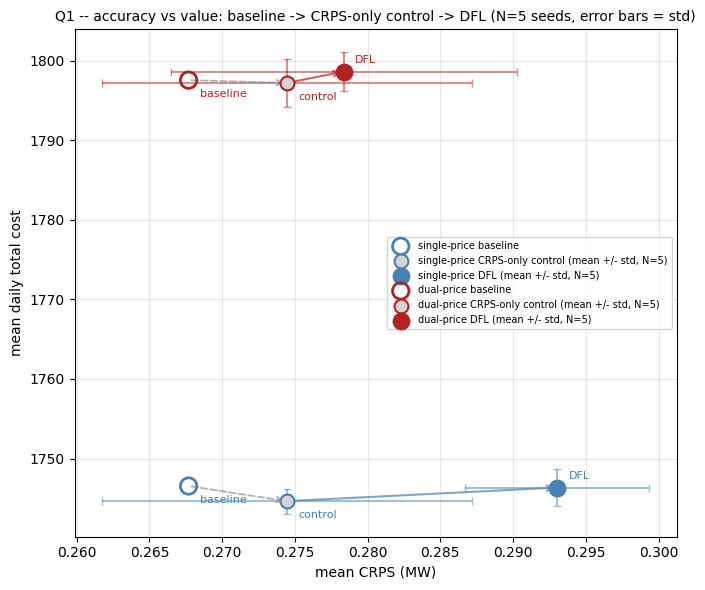

In [6]:
def plot_q1_scatter():
    """Both markets on ONE scatter -- baseline (single point), crps_only_retrained and
    DFL (both mean +/- std across the 5 seeds, error bars in both axes). Color = market;
    marker = forecaster (hollow baseline, half-filled control, filled DFL). Two arrows
    per market chain baseline -> control-mean -> DFL-mean, so the control's own shift
    (grey, "just more training") is visually separated from what DFL adds beyond it
    (colored) -- though per Q1's table, both means now sit well inside each other's error
    bars for both markets, which the plot should make visible rather than hide."""
    colors = {"single-price": "steelblue", "dual-price": "firebrick"}
    fig, ax = plt.subplots(figsize=(7, 6))

    def seed_stats(mode, base_id):
        crpss, costs = [], []
        for seed in SEEDS:
            fid = seed_variant(base_id, seed)
            frame = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                           & (all_df["forecaster_id"] == fid)]
            crpss.append(frame["crps"].mean())
            costs.append(frame["total_cost"].mean())
        crpss, costs = np.array(crpss), np.array(costs)
        return crpss.mean(), crpss.std(), costs.mean(), costs.std()

    for mode, color in colors.items():
        dfl_forecaster = dfl_id(mode)
        base_frame = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                             & (all_df["forecaster_id"] == "baseline")]
        base_crps, base_cost = base_frame["crps"].mean(), base_frame["total_cost"].mean()
        ctrl_crps, ctrl_crps_std, ctrl_cost, ctrl_cost_std = seed_stats(mode, "crps_only_retrained")
        dfl_crps, dfl_crps_std, dfl_cost, dfl_cost_std = seed_stats(mode, dfl_forecaster)

        ax.annotate("", xy=(ctrl_crps, ctrl_cost), xytext=(base_crps, base_cost),
                    arrowprops=dict(arrowstyle="->", color="grey", alpha=0.6, lw=1.3, linestyle="--"))
        ax.annotate("", xy=(dfl_crps, dfl_cost), xytext=(ctrl_crps, ctrl_cost),
                    arrowprops=dict(arrowstyle="->", color=color, alpha=0.7, lw=1.5))

        ax.scatter(base_crps, base_cost, s=140, facecolors="none",
                   edgecolors=color, linewidths=2, zorder=3, label=f"{mode} baseline")
        ax.errorbar(ctrl_crps, ctrl_cost, xerr=ctrl_crps_std, yerr=ctrl_cost_std, fmt="none",
                    ecolor=color, alpha=0.5, capsize=3, zorder=2)
        ax.scatter(ctrl_crps, ctrl_cost, s=100, facecolors="lightgrey",
                   edgecolors=color, linewidths=1.5, zorder=3, label=f"{mode} CRPS-only control (mean +/- std, N=5)")
        ax.errorbar(dfl_crps, dfl_cost, xerr=dfl_crps_std, yerr=dfl_cost_std, fmt="none",
                    ecolor=color, alpha=0.5, capsize=3, zorder=2)
        ax.scatter(dfl_crps, dfl_cost, s=140, color=color,
                   zorder=3, label=f"{mode} DFL (mean +/- std, N=5)")
        ax.annotate("baseline", (base_crps, base_cost),
                    textcoords="offset points", xytext=(8, -12), fontsize=8, color=color)
        ax.annotate("control", (ctrl_crps, ctrl_cost),
                    textcoords="offset points", xytext=(8, -12), fontsize=8, color=color)
        ax.annotate("DFL", (dfl_crps, dfl_cost),
                    textcoords="offset points", xytext=(8, 6), fontsize=8, color=color)

    ax.set_xlabel("mean CRPS (MW)")
    ax.set_ylabel("mean daily total cost")
    ax.set_title("Q1 -- accuracy vs value: baseline -> CRPS-only control -> DFL (N=5 seeds, error bars = std)", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    plt.show()


plot_q1_scatter()